# 01 Análise Exploratória do DDsmall

In [1]:
from pathlib import Path
import sys, json
sys.path.insert(0, str(Path('..').resolve()))

from src.data_loading import load_ddsmall
from collections import Counter
import matplotlib.pyplot as plt

ROOT = Path('..')
train = load_ddsmall(ROOT / 'data/raw/DDsmall/train/dd_corpus_small_train.json')
val   = load_ddsmall(ROOT / 'data/raw/DDsmall/val/dd_corpus_small_val.json')
test  = load_ddsmall(ROOT / 'data/raw/DDsmall/test/dd_corpus_small_test.json')

print(f'Train: {len(train)} | Val: {len(val)} | Test: {len(test)}')

Train: 4226 | Val: 212 | Test: 792


In [2]:
# Distribuição de entidades por classe
def count_labels(records):
    c = Counter()
    for r in records:
        for s in r['spans']:
            c[s['label']] += 1
    return c

print('Train:', count_labels(train))
print('Val:  ', count_labels(val))
print('Test: ', count_labels(test))

Train: Counter({'Location': 9862, 'Person': 3171, 'Organization': 2993})
Val:   Counter({'Location': 607, 'Person': 216, 'Organization': 195})
Test:  Counter({'Location': 1832, 'Person': 633, 'Organization': 592})


Média: 362 | Mediana: 238 | Max: 9553


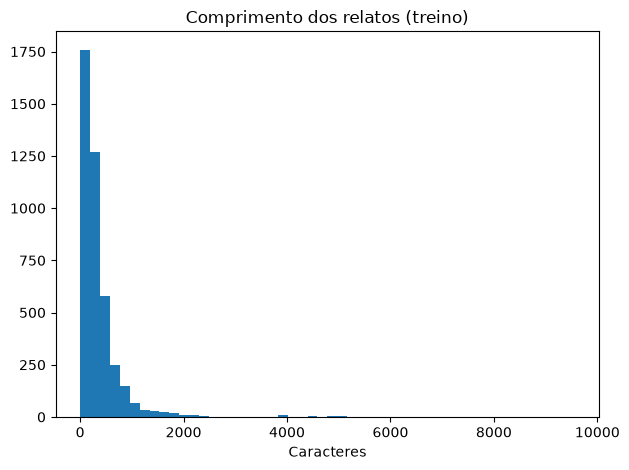

In [3]:
# Comprimento dos relatos (em caracteres)
import numpy as np

lengths = [len(r['text']) for r in train]
print(f'Média: {np.mean(lengths):.0f} | Mediana: {np.median(lengths):.0f} | Max: {max(lengths)}')

plt.hist(lengths, bins=50)
plt.xlabel('Caracteres')
plt.title('Comprimento dos relatos (treino)')
plt.tight_layout()
plt.savefig('../results/figures/relato_lengths.png', dpi=150)
plt.show()

In [4]:
# Exemplos de relatos anotados
for rec in train[:3]:
    print(rec['text'])
    for s in rec['spans']:
        print(f"  [{s['label']}] '{rec['text'][s['start']:s['end']]}'")
    print()

Casa onde fica guardada drogas dá facção comando vermelho , cocaína e maconha do Fernando beira mar , sob comando dos filhos de beira mar , armas , dinheoro , drogas , meliantes com arma ficam disparando tiros o dia todo . Isso fica numa Casa no beira mar
  [Organization] 'comando vermelho'
  [Person] 'Fernando beira mar'
  [Location] 'beira mar'
  [Location] 'beira mar'

De 4 a 8 homens armados montaram uma boca de fumo nessa rua . Eles se escondem e invadem a casa de moradores todos os dias . Fizeram barricadas nas duas esquinas da rua utilizando madeiras e pedras . Passam a noite toda gritando os preços das drogas e pulando muro . Intimidação de moradores são constantes . Encontram guarida na casa de um dos moradores chamado Pedro , que poe sinal é viciado
  [Person] 'Pedro'

Uso e tráfico de drogas na rua Germano Faber . Usuários e traficantes durante o dia e a noite usando drogas sem se importar com as pessoas passando . A rua tem crianças passeando durante o dia todo e tem um imp